In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!pip install pathspec
%pip install -q ultralytics transformers accelerate gdown opencv-python pillow pandas matplotlib tqdm addict imagesize
!pip install --extra-index-url https://developer.download.nvidia.com/compute/redist nvidia-dali-cuda120

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.3/57.3 kB 3.5 MB/s eta 0:00:00


# 02 - Generate Teacher Pseudo Labels for YOLOPv2 Finetuning

This Colab notebook builds a mixed CARLA + real dashcam dataset without using YOLOPv2 as its own labeler.

Teachers used here:
- Bounding boxes: YOLOv8x (Ultralytics / COCO), mapped into YOLOPv2's driving classes.
- Lane masks: Ultra-Fast-Lane-Detection-v2 (CULane ResNet-18 checkpoint).
- Drivable area masks: SegFormer-B2 fine-tuned on Cityscapes.

Output images and masks are written at 320x320 so they match the YOLOPv2 finetuning/export target.

## 1 - Colab Setup

In [ ]:

import os
import sys
import math
import shutil
import subprocess
from pathlib import Path

import cv2
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
from PIL import Image
from tqdm.auto import tqdm
import matplotlib.pyplot as plt

from google.colab import drive
drive.mount('/content/drive')

# Change this if your repo folder has a different Drive location.
PROJECT_ROOT = Path('/content/drive/MyDrive/sdcar-perception')
DATA_ROOT = PROJECT_ROOT / 'data'
CARLA_IMAGE_DIR = DATA_ROOT / 'carla' / 'images'
REAL_VIDEO_DIR = DATA_ROOT / 'real' / 'videos'
OUT_ROOT = DATA_ROOT / 'yolopv2_finetune'

IMAGE_SIZE = 640
TARGET_REAL_FRAMES = 5000
YOLO_CONF = 0.65
TEACHER_BATCH_SIZE = 16

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

OUT_IMAGES = OUT_ROOT / 'images'
OUT_LABELS = OUT_ROOT / 'labels'
OUT_LANE = OUT_ROOT / 'masks' / 'lane'
OUT_DRIVABLE = OUT_ROOT / 'masks' / 'drivable'
OUT_QA = OUT_ROOT / 'qa_samples'
for d in (OUT_IMAGES, OUT_LABELS, OUT_LANE, OUT_DRIVABLE, OUT_QA):
    d.mkdir(parents=True, exist_ok=True)

print('Project root:', PROJECT_ROOT)
print('CARLA images:', CARLA_IMAGE_DIR)
print('Real videos:', REAL_VIDEO_DIR)
print('Output:', OUT_ROOT)
print('Device:', DEVICE)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Project root: /content/drive/MyDrive/sdcar-perception
CARLA images: /content/drive/MyDrive/sdcar-perception/data/carla/images
Real videos: /content/drive/MyDrive/sdcar-perception/data/real/videos
Output: /content/drive/MyDrive/sdcar-perception/data/yolopv2_finetune
Device: cuda


## 2 - Inspect Dataset Structure

In [ ]:
def inspect_tree(root: Path, max_depth=3):
    rows = []
    root = Path(root)
    for path in sorted(root.rglob('*')):
        rel = path.relative_to(root)
        if len(rel.parts) > max_depth:
            continue
        if path.is_dir():
            kind, count = 'dir', sum(1 for _ in path.iterdir())
        else:
            kind, count = path.suffix.lower() or 'file', path.stat().st_size
        rows.append({'path': str(rel), 'kind': kind, 'count_or_bytes': count})
    return pd.DataFrame(rows)

summary = inspect_tree(DATA_ROOT)
display(summary)

carla_images = sorted(CARLA_IMAGE_DIR.glob('*.jpg')) + sorted(CARLA_IMAGE_DIR.glob('*.png'))
real_videos = sorted(REAL_VIDEO_DIR.glob('*.mp4')) + sorted(REAL_VIDEO_DIR.glob('*.mov')) + sorted(REAL_VIDEO_DIR.glob('*.avi'))
print(f'CARLA images: {len(carla_images)}')
print(f'Real videos: {len(real_videos)}')
for vp in real_videos:
    cap = cv2.VideoCapture(str(vp))
    fps = cap.get(cv2.CAP_PROP_FPS) or 0
    frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT) or 0)
    w = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH) or 0)
    h = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT) or 0)
    cap.release()
    duration = frames / fps if fps else 0
    print(f'{vp.name}: {frames} frames, {fps:.2f} fps, {duration:.1f}s, {w}x{h}')

,path,kind,count_or_bytes
0,carla,dir,1
1,carla/images,dir,1464
2,carla/images/carla_0000008.jpg,.jpg,106497
3,carla/images/carla_0000009.jpg,.jpg,108321
4,carla/images/carla_0000022.jpg,.jpg,131442
...,...,...,...
1472,yolopv2_finetune/labels,dir,0
1473,yolopv2_finetune/masks,dir,2
1474,yolopv2_finetune/masks/drivable,dir,0
1475,yolopv2_finetune/masks/lane,dir,0


CARLA images: 1464
Real videos: 2
VID_20260505_170306.mp4: 5419 frames, 28.03 fps, 193.3s, 1440x2560
VID_20260506_075826.mp4: 3883 frames, 29.52 fps, 131.5s, 1440x2560


## 3 - Download and Load Teacher Models

In [ ]:
TEACHER_DIR = Path('/content/teacher_models')
TEACHER_DIR.mkdir(parents=True, exist_ok=True)

# YOLOv8x auto-downloads yolov8x.pt the first time this runs.
from ultralytics import YOLO
box_teacher = YOLO('yolov8x.pt')

# SegFormer-B2 Cityscapes road segmentation.
from transformers import SegformerForSemanticSegmentation, SegformerImageProcessor
segformer_name = 'nvidia/segformer-b2-finetuned-cityscapes-1024-1024'
seg_processor = SegformerImageProcessor.from_pretrained(segformer_name)
seg_model = SegformerForSemanticSegmentation.from_pretrained(segformer_name).to(DEVICE).eval()
seg_id2label = {int(k): v.lower() for k, v in seg_model.config.id2label.items()}
ROAD_CLASS_IDS = [idx for idx, name in seg_id2label.items() if name == 'road']
if not ROAD_CLASS_IDS:
    raise RuntimeError(f'Could not find Cityscapes road class in {seg_id2label}')
print('SegFormer road ids:', ROAD_CLASS_IDS)

# UFLD-v2 official repo + CULane ResNet-18 teacher checkpoint.
UFLD_ROOT = Path('/content/Ultra-Fast-Lane-Detection-v2')
if not UFLD_ROOT.exists():
    subprocess.run(['git', 'clone', 'https://github.com/cfzd/Ultra-Fast-Lane-Detection-v2', str(UFLD_ROOT)], check=True)

ufld_ckpt = TEACHER_DIR / 'ufldv2_culane_res18.pth'
if not ufld_ckpt.exists():
    # Official README Google Drive id for CULane ResNet-18.
    subprocess.run(['gdown', '--id', '1oEjJraFr-3lxhX_OXduAGFWalWa6Xh3W', '-O', str(ufld_ckpt)], check=True)

# Patch the cloned UFLD CULane model so inference does not import training-only
# DALI helpers through utils.common, and so CPU fallback works if Colab has no GPU.
model_culane_py = UFLD_ROOT / 'model' / 'model_culane.py'
model_culane_text = model_culane_py.read_text(encoding='utf-8')
if 'from utils.common import initialize_weights' in model_culane_text:
    init_helper = """

def initialize_weights(*models):
    for model in models:
        for m in model.modules():
            if isinstance(m, torch.nn.Conv2d):
                torch.nn.init.kaiming_normal_(m.weight, nonlinearity='relu')
                if m.bias is not None:
                    torch.nn.init.constant_(m.bias, 0)
            elif isinstance(m, torch.nn.Linear):
                m.weight.data.normal_(0.0, std=0.01)
                if m.bias is not None:
                    torch.nn.init.constant_(m.bias, 0)
            elif isinstance(m, torch.nn.BatchNorm2d):
                torch.nn.init.constant_(m.weight, 1)
                torch.nn.init.constant_(m.bias, 0)
"""
    model_culane_text = model_culane_text.replace('from utils.common import initialize_weights', init_helper)
model_culane_text = model_culane_text.replace(
    ').cuda()',
    ').to(torch.device(\"cuda\" if torch.cuda.is_available() else \"cpu\"))',
)
model_culane_py.write_text(model_culane_text, encoding='utf-8')

sys.path.insert(0, str(UFLD_ROOT))
from utils.config import Config
from model.model_culane import get_model
import torchvision.transforms as T



def pred2coords(pred, row_anchor, col_anchor, local_width=1, original_image_width=1640, original_image_height=590):
    batch_size, num_grid_row, num_cls_row, num_lane_row = pred['loc_row'].shape
    batch_size, num_grid_col, num_cls_col, num_lane_col = pred['loc_col'].shape
    max_indices_row = pred['loc_row'].argmax(1).cpu()
    valid_row = pred['exist_row'].argmax(1).cpu()
    max_indices_col = pred['loc_col'].argmax(1).cpu()
    valid_col = pred['exist_col'].argmax(1).cpu()
    pred['loc_row'] = pred['loc_row'].cpu()
    pred['loc_col'] = pred['loc_col'].cpu()
    coords = []
    row_lane_idx = [1, 2]
    col_lane_idx = [0, 3]

    for i in row_lane_idx:
        lane = []
        if valid_row[0, :, i].sum() > num_cls_row / 2:
            for k in range(valid_row.shape[1]):
                if valid_row[0, k, i]:
                    all_ind = torch.tensor(list(range(
                        max(0, max_indices_row[0, k, i] - local_width),
                        min(num_grid_row - 1, max_indices_row[0, k, i] + local_width) + 1,
                    )))
                    out_tmp = (pred['loc_row'][0, all_ind, k, i].softmax(0) * all_ind.float()).sum() + 0.5
                    out_tmp = out_tmp / (num_grid_row - 1) * original_image_width
                    lane.append((int(out_tmp), int(row_anchor[k] * original_image_height)))
        coords.append(lane)

    for i in col_lane_idx:
        lane = []
        if valid_col[0, :, i].sum() > num_cls_col / 4:
            for k in range(valid_col.shape[1]):
                if valid_col[0, k, i]:
                    all_ind = torch.tensor(list(range(
                        max(0, max_indices_col[0, k, i] - local_width),
                        min(num_grid_col - 1, max_indices_col[0, k, i] + local_width) + 1,
                    )))
                    out_tmp = (pred['loc_col'][0, all_ind, k, i].softmax(0) * all_ind.float()).sum() + 0.5
                    out_tmp = out_tmp / (num_grid_col - 1) * original_image_height
                    lane.append((int(col_anchor[k] * original_image_width), int(out_tmp)))
        coords.append(lane)
    return coords

ufld_cfg = Config.fromfile(str(UFLD_ROOT / 'configs' / 'culane_res18.py'))
ufld_cfg.batch_size = 1
ufld_cfg.test_model = str(ufld_ckpt)
ufld_cfg.row_anchor = np.linspace(0.42, 1, ufld_cfg.num_row)
ufld_cfg.col_anchor = np.linspace(0, 1, ufld_cfg.num_col)

lane_teacher = get_model(ufld_cfg)
state = torch.load(str(ufld_ckpt), map_location='cpu')
state_dict = state.get('model', state)
state_dict = {k.replace('module.', ''): v for k, v in state_dict.items()}
lane_teacher.load_state_dict(state_dict, strict=False)
lane_teacher = lane_teacher.to(DEVICE).eval()

lane_resize = T.Resize((int(ufld_cfg.train_height / ufld_cfg.crop_ratio), ufld_cfg.train_width))
lane_to_tensor = T.Compose([
    T.ToTensor(),
    T.Normalize((0.485, 0.456, 0.406), (0.229, 0.224, 0.225)),
])

def prepare_lane_tensor(pil_image):
    resized = lane_resize(pil_image)
    resized_h = int(ufld_cfg.train_height / ufld_cfg.crop_ratio)
    crop_top = max(0, resized_h - ufld_cfg.train_height)
    cropped = T.functional.crop(
        resized,
        top=crop_top,
        left=0,
        height=ufld_cfg.train_height,
        width=ufld_cfg.train_width,
    )
    return lane_to_tensor(cropped)

print('Teachers loaded.')

Loading weights:   0%|          | 0/380 [00:00<?, ?it/s]

SegFormer road ids: [0]
Teachers loaded.


## 4 - Label Helpers

In [ ]:
YOLOPV2_LABELS = [
    'car', 'truck', 'bus', 'person', 'rider',
    'bicycle', 'motorcycle', 'traffic light', 'traffic sign', 'train',
]
YOLOPV2_CLASS_TO_ID = {name: idx for idx, name in enumerate(YOLOPV2_LABELS)}

# COCO -> YOLOPv2/BDD-style driving classes. COCO has no direct rider class.
COCO_TO_YOLOPV2 = {
    'person': 'person',
    'bicycle': 'bicycle',
    'car': 'car',
    'motorcycle': 'motorcycle',
    'bus': 'bus',
    'train': 'train',
    'truck': 'truck',
    'traffic light': 'traffic light',
    'stop sign': 'traffic sign',
}


def letterbox_image(frame_bgr, size=IMAGE_SIZE, pad_value=(114, 114, 114)):
    h, w = frame_bgr.shape[:2]
    scale = min(size / w, size / h)
    new_w, new_h = int(round(w * scale)), int(round(h * scale))
    resized = cv2.resize(frame_bgr, (new_w, new_h), interpolation=cv2.INTER_AREA)
    canvas = np.full((size, size, 3), pad_value, dtype=np.uint8)
    pad_x = (size - new_w) // 2
    pad_y = (size - new_h) // 2
    canvas[pad_y:pad_y + new_h, pad_x:pad_x + new_w] = resized
    return canvas, scale, pad_x, pad_y


def letterbox_mask(mask, size=IMAGE_SIZE):
    h, w = mask.shape[:2]
    scale = min(size / w, size / h)
    new_w, new_h = int(round(w * scale)), int(round(h * scale))
    resized = cv2.resize(mask, (new_w, new_h), interpolation=cv2.INTER_NEAREST)
    canvas = np.zeros((size, size), dtype=np.uint8)
    pad_x = (size - new_w) // 2
    pad_y = (size - new_h) // 2
    canvas[pad_y:pad_y + new_h, pad_x:pad_x + new_w] = resized
    return canvas


def transform_detections_to_letterbox(detections, scale, pad_x, pad_y, size=IMAGE_SIZE):
    transformed = []
    for det in detections:
        d = det.copy()
        d['x1'] = float(np.clip(det['x1'] * scale + pad_x, 0, size - 1))
        d['y1'] = float(np.clip(det['y1'] * scale + pad_y, 0, size - 1))
        d['x2'] = float(np.clip(det['x2'] * scale + pad_x, 0, size - 1))
        d['y2'] = float(np.clip(det['y2'] * scale + pad_y, 0, size - 1))
        transformed.append(d)
    return transformed


def _parse_yolo_result(result):
    detections = []
    names = result.names
    if result.boxes is None:
        return detections
    for box in result.boxes:
        coco_name = names[int(box.cls.item())]
        mapped = COCO_TO_YOLOPV2.get(coco_name)
        if mapped is None:
            continue
        x1, y1, x2, y2 = box.xyxy[0].detach().cpu().numpy().astype(float).tolist()
        detections.append({
            'cls': YOLOPV2_CLASS_TO_ID[mapped],
            'label': mapped,
            'conf': float(box.conf.item()),
            'x1': x1, 'y1': y1, 'x2': x2, 'y2': y2,
        })
    return detections


def yolo_box_teacher_batch(frames_bgr, conf=YOLO_CONF):
    results = box_teacher.predict(
        frames_bgr,
        imgsz=640,
        conf=conf,
        verbose=False,
        device=0 if DEVICE == 'cuda' else 'cpu',
        batch=len(frames_bgr),
    )
    return [_parse_yolo_result(result) for result in results]


@torch.inference_mode()
def segformer_drivable_masks_batch(frames_bgr):
    rgbs = [cv2.cvtColor(frame, cv2.COLOR_BGR2RGB) for frame in frames_bgr]
    inputs = seg_processor(images=rgbs, return_tensors='pt').to(DEVICE)
    logits = seg_model(**inputs).logits
    masks = []
    for i, rgb in enumerate(rgbs):
        up = F.interpolate(logits[i:i + 1], size=rgb.shape[:2], mode='bilinear', align_corners=False)
        pred = up.argmax(dim=1)[0].detach().cpu().numpy().astype(np.uint8)
        masks.append(np.isin(pred, ROAD_CLASS_IDS).astype(np.uint8) * 255)
    return masks


@torch.inference_mode()
def ufld_lane_masks_batch(frames_bgr, thickness=5):
    rgbs = [cv2.cvtColor(frame, cv2.COLOR_BGR2RGB) for frame in frames_bgr]
    tensors = [prepare_lane_tensor(Image.fromarray(rgb)) for rgb in rgbs]
    batch = torch.stack(tensors, dim=0).to(DEVICE)
    pred = lane_teacher(batch)
    masks = []
    for i, rgb in enumerate(rgbs):
        h, w = rgb.shape[:2]
        pred_i = {k: v[i:i + 1] for k, v in pred.items()}
        coords = pred2coords(
            pred_i,
            ufld_cfg.row_anchor,
            ufld_cfg.col_anchor,
            original_image_width=w,
            original_image_height=h,
        )
        mask = np.zeros((h, w), dtype=np.uint8)
        for lane in coords:
            pts = [(int(x), int(y)) for x, y in lane if 0 <= int(x) < w and 0 <= int(y) < h]
            if len(pts) >= 2:
                cv2.polylines(mask, [np.array(pts, dtype=np.int32)], isClosed=False, color=255, thickness=thickness)
            for pt in pts:
                cv2.circle(mask, pt, max(2, thickness // 2), 255, -1)
        masks.append(mask)
    return masks


def write_yolo_labels(detections, out_path: Path, img_w: int = IMAGE_SIZE, img_h: int = IMAGE_SIZE):
    lines = []
    for det in detections:
        x1 = np.clip(det['x1'], 0, img_w - 1)
        y1 = np.clip(det['y1'], 0, img_h - 1)
        x2 = np.clip(det['x2'], 0, img_w - 1)
        y2 = np.clip(det['y2'], 0, img_h - 1)
        bw = max(float(x2 - x1), 1.0)
        bh = max(float(y2 - y1), 1.0)
        cx = (float(x1) + bw * 0.5) / img_w
        cy = (float(y1) + bh * 0.5) / img_h
        lines.append(f"{int(det['cls'])} {cx:.6f} {cy:.6f} {bw / img_w:.6f} {bh / img_h:.6f}")
    out_path.write_text('\n'.join(lines), encoding='utf-8')


def save_labeled_batch(items):
    """items: list of (frame_bgr, stem, source_domain, source_name, frame_index)."""
    frames = [item[0] for item in items]
    box_batches = yolo_box_teacher_batch(frames)
    lane_masks = ufld_lane_masks_batch(frames)
    drivable_masks = segformer_drivable_masks_batch(frames)

    rows = []
    for item, detections, lane_mask, drivable_mask in zip(items, box_batches, lane_masks, drivable_masks):
        frame_bgr, stem, source_domain, source_name, frame_index = item
        img_letterbox, scale, pad_x, pad_y = letterbox_image(frame_bgr)
        lane_letterbox = letterbox_mask(lane_mask)
        drivable_letterbox = letterbox_mask(drivable_mask)
        detections_letterbox = transform_detections_to_letterbox(detections, scale, pad_x, pad_y)

        img_path = OUT_IMAGES / f'{stem}.jpg'
        label_path = OUT_LABELS / f'{stem}.txt'
        lane_path = OUT_LANE / f'{stem}.png'
        drivable_path = OUT_DRIVABLE / f'{stem}.png'

        cv2.imwrite(str(img_path), img_letterbox)
        cv2.imwrite(str(lane_path), lane_letterbox)
        cv2.imwrite(str(drivable_path), drivable_letterbox)
        write_yolo_labels(detections_letterbox, label_path)

        rows.append({
            'image_path': str(img_path),
            'label_path': str(label_path),
            'lane_mask_path': str(lane_path),
            'drivable_mask_path': str(drivable_path),
            'domain': source_domain,
            'is_real': int(source_domain == 'real'),
            'source_name': source_name,
            'frame_index': frame_index if frame_index is not None else '',
            'width': IMAGE_SIZE,
            'height': IMAGE_SIZE,
            'letterbox_scale': scale,
            'letterbox_pad_x': pad_x,
            'letterbox_pad_y': pad_y,
            'num_objects': len(detections_letterbox),
        })
    return rows


## 5 - Real Video Sampling Plan (~5000 frames)

In [ ]:
def video_meta(video_path):
    cap = cv2.VideoCapture(str(video_path))
    if not cap.isOpened():
        raise RuntimeError(f'Cannot open video: {video_path}')
    fps = cap.get(cv2.CAP_PROP_FPS) or 30.0
    frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT) or 0)
    w = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH) or 0)
    h = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT) or 0)
    cap.release()
    return {'path': video_path, 'fps': fps, 'frames': frames, 'width': w, 'height': h, 'duration_s': frames / fps if fps else 0}

video_infos = [video_meta(p) for p in real_videos]
total_video_frames = sum(v['frames'] for v in video_infos)
remaining = TARGET_REAL_FRAMES
sampling_plan = []
for i, info in enumerate(video_infos):
    if i == len(video_infos) - 1:
        target = remaining
    else:
        target = int(round(TARGET_REAL_FRAMES * info['frames'] / max(total_video_frames, 1)))
        remaining -= target
    target = min(target, info['frames'])
    sampled_fps = target / max(info['duration_s'], 1e-6)
    sampling_plan.append({**info, 'target_frames': target, 'sampled_fps': sampled_fps})

plan_df = pd.DataFrame([{k: str(v) if isinstance(v, Path) else v for k, v in row.items()} for row in sampling_plan])
display(plan_df[['path', 'frames', 'fps', 'duration_s', 'width', 'height', 'target_frames', 'sampled_fps']])
print('Total sampled real frames:', sum(p['target_frames'] for p in sampling_plan))

,path,frames,fps,duration_s,width,height,target_frames,sampled_fps
0,/content/drive/MyDrive/sdcar-perception/data/r...,5419,28.027071,193.348778,1440,2560,2913,15.066038
1,/content/drive/MyDrive/sdcar-perception/data/r...,3883,29.522750,131.525689,1440,2560,2087,15.867623


Total sampled real frames: 5000


## 6 - Build Final Dataset

In [21]:
def iter_selected_video_frames(video_path: Path, target_count: int):
    cap = cv2.VideoCapture(str(video_path))
    total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT) or 0)
    if total <= 0 or target_count <= 0:
        cap.release()
        return
    indices = np.unique(np.linspace(0, total - 1, num=target_count, dtype=np.int64))
    for frame_idx in tqdm(indices, desc=video_path.name):
        cap.set(cv2.CAP_PROP_POS_FRAMES, int(frame_idx))
        ok, frame = cap.read()
        if ok:
            yield int(frame_idx), frame
    cap.release()


def flush_batch(batch, rows):
    if not batch:
        return
    try:
        rows.extend(save_labeled_batch(batch))
    except torch.cuda.OutOfMemoryError:
        torch.cuda.empty_cache()
        if len(batch) == 1:
            raise
        mid = len(batch) // 2
        flush_batch(batch[:mid], rows)
        flush_batch(batch[mid:], rows)

rows = []
batch = []

# CARLA synthetic frames.
for img_path in tqdm(carla_images, desc='CARLA images'):
    frame = cv2.imread(str(img_path))
    if frame is None:
        continue
    stem = f'carla_{img_path.stem}'
    batch.append((frame, stem, 'simulated', img_path.name, None))
    if len(batch) >= TEACHER_BATCH_SIZE:
        flush_batch(batch, rows)
        batch = []
flush_batch(batch, rows)
batch = []

# Real dashcam frames sampled to approximately TARGET_REAL_FRAMES total.
for info in sampling_plan:
    video_path = info['path']
    for frame_idx, frame in iter_selected_video_frames(video_path, info['target_frames']):
        stem = f'real_{video_path.stem}_{frame_idx:06d}'
        batch.append((frame, stem, 'real', video_path.name, frame_idx))
        if len(batch) >= TEACHER_BATCH_SIZE:
            flush_batch(batch, rows)
            batch = []
flush_batch(batch, rows)

manifest = pd.DataFrame(rows)
manifest_path = OUT_ROOT / 'manifest.csv'
manifest.to_csv(manifest_path, index=False)
print(f'Saved {len(manifest)} labeled frames to {OUT_ROOT}')
print(f'Manifest: {manifest_path}')
display(manifest.groupby('domain').agg(frames=('image_path', 'count'), objects=('num_objects', 'sum')).reset_index())


CARLA images:   0%|          | 0/1464 [00:00<?, ?it/s]

VID_20260505_170306.mp4:   0%|          | 0/2913 [00:00<?, ?it/s]

VID_20260506_075826.mp4:   0%|          | 0/2087 [00:00<?, ?it/s]

Saved 6464 labeled frames to /content/drive/MyDrive/sdcar-perception/data/yolopv2_finetune
Manifest: /content/drive/MyDrive/sdcar-perception/data/yolopv2_finetune/manifest.csv


,domain,frames,objects
0,real,5000,11566
1,simulated,1464,3512


## 7 - Visual QA Samples

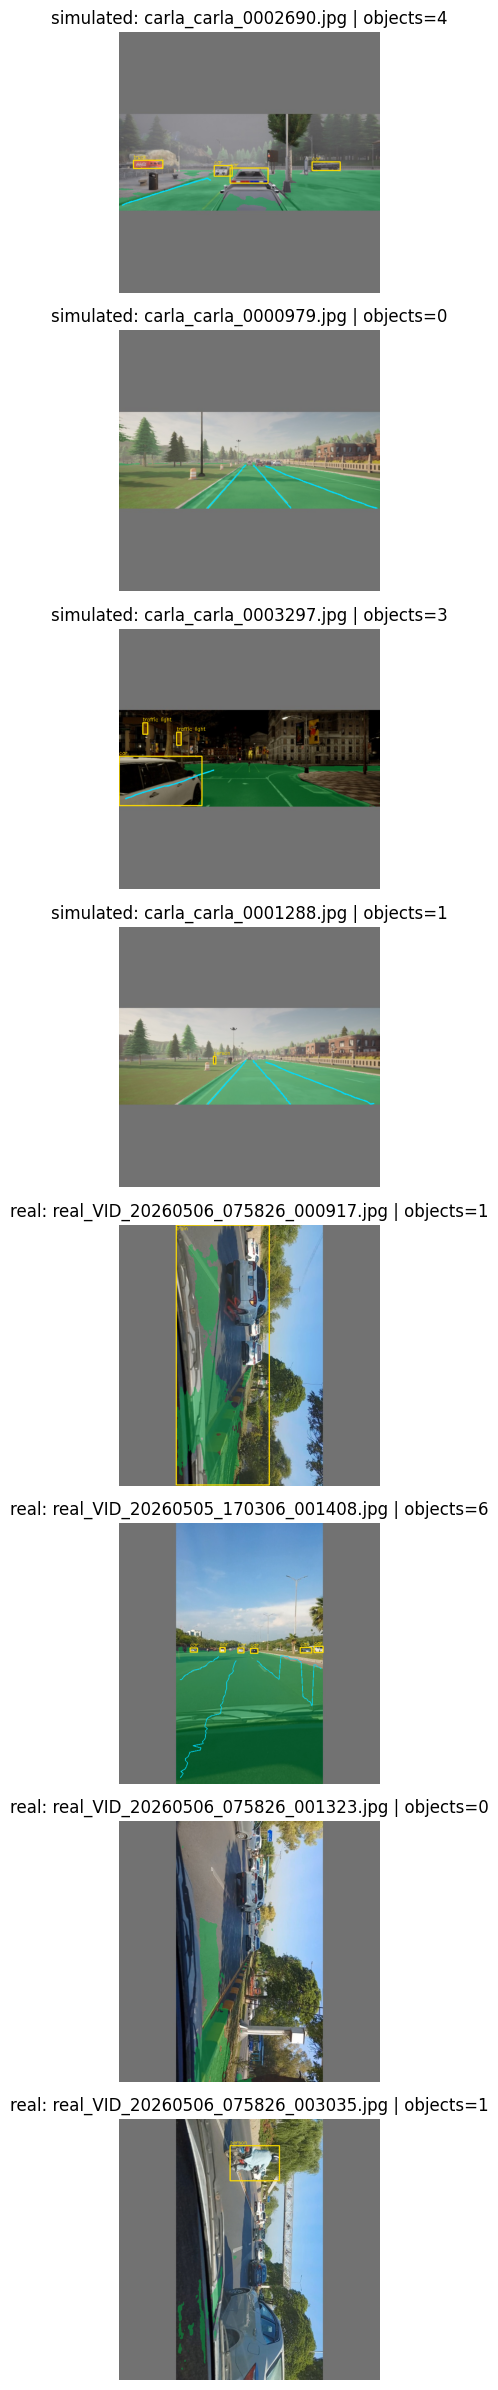

QA overlays saved to /content/drive/MyDrive/sdcar-perception/data/yolopv2_finetune/qa_samples


In [22]:
def read_yolo_label_file(label_path: Path, img_w=IMAGE_SIZE, img_h=IMAGE_SIZE):
    boxes = []
    if not label_path.exists():
        return boxes
    for line in label_path.read_text(encoding='utf-8').splitlines():
        parts = line.split()
        if len(parts) != 5:
            continue
        cls, cx, cy, bw, bh = map(float, parts)
        x1 = int((cx - bw / 2) * img_w)
        y1 = int((cy - bh / 2) * img_h)
        x2 = int((cx + bw / 2) * img_w)
        y2 = int((cy + bh / 2) * img_h)
        boxes.append((int(cls), x1, y1, x2, y2))
    return boxes


def overlay_sample(row):
    img = cv2.imread(row.image_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    lane = cv2.imread(row.lane_mask_path, cv2.IMREAD_GRAYSCALE)
    drivable = cv2.imread(row.drivable_mask_path, cv2.IMREAD_GRAYSCALE)
    vis = img.copy()
    vis[drivable > 0] = (0.55 * vis[drivable > 0] + np.array([0, 180, 70]) * 0.45).astype(np.uint8)
    vis[lane > 0] = np.array([0, 220, 255], dtype=np.uint8)
    for cls, x1, y1, x2, y2 in read_yolo_label_file(Path(row.label_path)):
        cv2.rectangle(vis, (x1, y1), (x2, y2), (255, 220, 0), 2)
        cv2.putText(vis, YOLOPV2_LABELS[cls], (x1, max(12, y1 - 4)), cv2.FONT_HERSHEY_SIMPLEX, 0.4, (255, 220, 0), 1)
    return vis

sample_rows = pd.concat([
    manifest[manifest.domain == 'simulated'].sample(min(4, (manifest.domain == 'simulated').sum()), random_state=7),
    manifest[manifest.domain == 'real'].sample(min(4, (manifest.domain == 'real').sum()), random_state=7),
])

fig, axes = plt.subplots(len(sample_rows), 1, figsize=(6, 3 * len(sample_rows)))
if len(sample_rows) == 1:
    axes = [axes]
for ax, (_, row) in zip(axes, sample_rows.iterrows()):
    vis = overlay_sample(row)
    ax.imshow(vis)
    ax.set_title(f"{row.domain}: {Path(row.image_path).name} | objects={row.num_objects}")
    ax.axis('off')
    cv2.imwrite(str(OUT_QA / f"qa_{Path(row.image_path).stem}.jpg"), cv2.cvtColor(vis, cv2.COLOR_RGB2BGR))
plt.tight_layout()
plt.show()
print('QA overlays saved to', OUT_QA)

## 8 - Final Layout

The generated dataset is ready for `notebooks/03_finetune_yolopv2.ipynb`:

```text
data/yolopv2_finetune/
  images/*.jpg              # 320x320 RGB frames from CARLA and real videos
  labels/*.txt              # YOLO format boxes in YOLOPv2 class order
  masks/lane/*.png          # UFLD-v2 lane masks, 0/255
  masks/drivable/*.png      # SegFormer road/drivable masks, 0/255
  manifest.csv              # paths + domain/is_real metadata
  qa_samples/*.jpg          # visual inspection overlays
```

Important: this notebook intentionally does not use YOLOPv2 for pseudo-labeling; YOLOPv2 only consumes these labels later during finetuning.

## 9 - Rotate and Relabel Mis-Oriented Real Video

Run this after `6 - Build Final Dataset` and before augmentation. It rotates raw frames from `VID_20260506_075826` 90 degrees counterclockwise, reruns all teacher models, and overwrites that video's images, boxes, lane masks, and drivable masks in the final dataset.


In [24]:
# Re-label the mis-oriented real video from corrected raw frames.
# This overwrites the existing final dataset files for real_VID_20260506_075826_*.

from pathlib import Path
import cv2
import numpy as np
import pandas as pd
from tqdm.auto import tqdm

ROTATE_VIDEO_STEM = 'VID_20260506_075826'
manifest_path = OUT_ROOT / 'manifest.csv'
manifest = pd.read_csv(manifest_path)

# If augmentation was already run, drop augmented rows from the manifest so the
# next augmentation cell can recreate them from the corrected base labels.
if 'is_augmented' in manifest.columns and manifest['is_augmented'].fillna(0).astype(int).eq(1).any():
    removed_aug = int(manifest['is_augmented'].fillna(0).astype(int).sum())
    manifest = manifest[manifest['is_augmented'].fillna(0).astype(int) == 0].copy()
    print(f'Dropped {removed_aug} augmented rows from manifest; rerun the augmentation cell after this one.')

rotated_infos = [info for info in sampling_plan if Path(info['path']).stem == ROTATE_VIDEO_STEM]
if not rotated_infos:
    raise RuntimeError(f'No sampling_plan entry found for {ROTATE_VIDEO_STEM}')

new_rows = []
batch = []

for info in rotated_infos:
    video_path = info['path']
    for frame_idx, frame in iter_selected_video_frames(video_path, info['target_frames']):
        corrected_frame = cv2.rotate(frame, cv2.ROTATE_90_COUNTERCLOCKWISE)
        stem = f'real_{video_path.stem}_{frame_idx:06d}'
        batch.append((corrected_frame, stem, 'real', video_path.name, frame_idx))
        if len(batch) >= TEACHER_BATCH_SIZE:
            new_rows.extend(save_labeled_batch(batch))
            batch = []

if batch:
    new_rows.extend(save_labeled_batch(batch))

if not new_rows:
    raise RuntimeError(f'No frames were relabeled for {ROTATE_VIDEO_STEM}')

new_df = pd.DataFrame(new_rows)
new_df['rotation_corrected_before_labeling'] = 1
new_df['rotation_correction'] = 'raw_frame_90_ccw_then_relabel'

if 'rotation_corrected_before_labeling' not in manifest.columns:
    manifest['rotation_corrected_before_labeling'] = 0
if 'rotation_correction' not in manifest.columns:
    manifest['rotation_correction'] = ''

relabel_names = set(new_df['image_path'].map(lambda x: Path(x).name))
keep = ~manifest['image_path'].map(lambda x: Path(x).name).isin(relabel_names)
replaced = int((~keep).sum())
manifest = pd.concat([manifest[keep], new_df], ignore_index=True)
manifest.to_csv(manifest_path, index=False)

print(f'Relabeled corrected frames: {len(new_df)}')
print(f'Replaced existing manifest rows: {replaced}')
print(f'Manifest saved: {manifest_path}')
display(manifest.groupby(['domain', 'rotation_corrected_before_labeling']).agg(frames=('image_path', 'count'), objects=('num_objects', 'sum')).reset_index())


VID_20260506_075826.mp4:   0%|          | 0/2087 [00:00<?, ?it/s]

KeyboardInterrupt: 

## 10 - 2x Dataset Augmentation

Run this after the rotation/relabeling cell. It adds one augmented copy per non-augmented frame while keeping YOLO boxes, lane masks, and drivable masks aligned.


In [26]:
# Add one augmented copy per base frame, doubling the dataset size.

%pip install -q albumentations

from pathlib import Path
import cv2
import numpy as np
import pandas as pd
import albumentations as A
from tqdm.auto import tqdm

manifest_path = OUT_ROOT / 'manifest.csv'
manifest = pd.read_csv(manifest_path)


def _sanitize_yolo_box(cx, cy, w, h):
    cx = float(cx)
    cy = float(cy)
    w = float(w)
    h = float(h)
    w = max(0.0, min(1.0, w))
    h = max(0.0, min(1.0, h))
    cx = max(0.0, min(1.0, cx))
    cy = max(0.0, min(1.0, cy))
    x_min = max(cx - w / 2.0, 0.0)
    x_max = min(cx + w / 2.0, 1.0)
    y_min = max(cy - h / 2.0, 0.0)
    y_max = min(cy + h / 2.0, 1.0)
    new_w = x_max - x_min
    new_h = y_max - y_min
    if new_w <= 1e-6 or new_h <= 1e-6:
        return None
    new_cx = x_min + new_w / 2.0
    new_cy = y_min + new_h / 2.0
    return [new_cx, new_cy, new_w, new_h]


def read_yolo_file(label_path: Path):
    boxes, labels = [], []
    if not label_path.exists():
        return boxes, labels
    for line in label_path.read_text(encoding='utf-8').splitlines():
        parts = line.strip().split()
        if len(parts) != 5:
            continue
        cls, cx, cy, w, h = parts
        sanitized = _sanitize_yolo_box(cx, cy, w, h)
        if sanitized is None:
            continue
        labels.append(int(float(cls)))
        boxes.append(sanitized)
    return boxes, labels


def write_yolo_file(label_path: Path, boxes, labels):
    lines = []
    for cls, box in zip(labels, boxes):
        cx, cy, w, h = [float(v) for v in box]
        cx = float(np.clip(cx, 0.0, 1.0))
        cy = float(np.clip(cy, 0.0, 1.0))
        w = float(np.clip(w, 0.0, 1.0))
        h = float(np.clip(h, 0.0, 1.0))
        if w <= 1e-6 or h <= 1e-6:
            continue
        lines.append(f'{int(cls)} {cx:.6f} {cy:.6f} {w:.6f} {h:.6f}')
    label_path.write_text('\n'.join(lines), encoding='utf-8')


if 'is_augmented' not in manifest.columns:
    manifest['is_augmented'] = 0
if 'augmentation_parent' not in manifest.columns:
    manifest['augmentation_parent'] = ''

aug = A.Compose(
    [
        A.HorizontalFlip(p=0.45),
        A.VerticalFlip(p=0.03),
        A.Affine(
            scale=(0.92, 1.08),
            translate_percent=(-0.06, 0.06),
            rotate=(-7, 7),
            shear=(-8, 8),
            border_mode=cv2.BORDER_CONSTANT,
            p=0.85,
        ),
        A.OneOf([
            A.GaussNoise(p=1.0),
            A.ISONoise(p=1.0),
        ], p=0.35),
        A.OneOf([
            A.MotionBlur(blur_limit=5, p=1.0),
            A.GaussianBlur(blur_limit=(3, 5), p=1.0),
        ], p=0.25),
        A.Sharpen(alpha=(0.15, 0.45), lightness=(0.7, 1.3), p=0.25),
        A.RandomBrightnessContrast(brightness_limit=0.25, contrast_limit=0.25, p=0.55),
        A.HueSaturationValue(hue_shift_limit=8, sat_shift_limit=20, val_shift_limit=18, p=0.35),
        A.RGBShift(r_shift_limit=18, g_shift_limit=12, b_shift_limit=18, p=0.30),
        A.ColorJitter(brightness=0.15, contrast=0.15, saturation=0.15, hue=0.04, p=0.30),
    ],
    bbox_params=A.BboxParams(
        format='yolo',
        label_fields=['class_labels'],
        min_area=4,
        min_visibility=0.12,
    ),
)

base_rows = manifest[manifest['is_augmented'].fillna(0).astype(int) == 0].copy()
existing_aug_parents = set(
    manifest.loc[manifest['is_augmented'].fillna(0).astype(int) == 1, 'augmentation_parent']
    .fillna('')
    .astype(str)
    .tolist()
)
if existing_aug_parents:
    base_rows = base_rows[~base_rows['image_path'].astype(str).isin(existing_aug_parents)].copy()

if base_rows.empty:
    print('No new base rows to augment. Existing augmented rows already cover the base set.')
else:
    new_rows = []

    for _, row in tqdm(base_rows.iterrows(), total=len(base_rows), desc='2x augmentation'):
        img_path = Path(row['image_path'])
        label_path = Path(row['label_path'])
        lane_path = Path(row['lane_mask_path'])
        drivable_path = Path(row['drivable_mask_path'])

        image = cv2.imread(str(img_path))
        lane = cv2.imread(str(lane_path), cv2.IMREAD_GRAYSCALE)
        drivable = cv2.imread(str(drivable_path), cv2.IMREAD_GRAYSCALE)
        if image is None or lane is None or drivable is None:
            print('Skipping missing files for', img_path)
            continue

        boxes, labels = read_yolo_file(label_path)
        transformed = aug(
            image=image,
            masks=[lane, drivable],
            bboxes=boxes,
            class_labels=labels,
        )

        aug_image = transformed['image']
        aug_lane, aug_drivable = transformed['masks']
        aug_boxes = transformed['bboxes']
        aug_labels = transformed['class_labels']

        stem = f'aug_{img_path.stem}'
        aug_img_path = OUT_IMAGES / f'{stem}.jpg'
        aug_label_path = OUT_LABELS / f'{stem}.txt'
        aug_lane_path = OUT_LANE / f'{stem}.png'
        aug_drivable_path = OUT_DRIVABLE / f'{stem}.png'

        cv2.imwrite(str(aug_img_path), aug_image)
        cv2.imwrite(str(aug_lane_path), aug_lane)
        cv2.imwrite(str(aug_drivable_path), aug_drivable)
        write_yolo_file(aug_label_path, aug_boxes, aug_labels)

        out_row = row.copy()
        out_row['image_path'] = str(aug_img_path)
        out_row['label_path'] = str(aug_label_path)
        out_row['lane_mask_path'] = str(aug_lane_path)
        out_row['drivable_mask_path'] = str(aug_drivable_path)
        out_row['source_name'] = f"augmented:{row.get('source_name', img_path.name)}"
        out_row['num_objects'] = len(aug_boxes)
        out_row['is_augmented'] = 1
        out_row['augmentation_parent'] = str(img_path)
        new_rows.append(out_row)

    if new_rows:
        manifest = pd.concat([manifest, pd.DataFrame(new_rows)], ignore_index=True)
        manifest.to_csv(manifest_path, index=False)

    print(f'Added augmented frames: {len(new_rows)}')
    print(f'Final dataset rows: {len(manifest)}')
    display(manifest.groupby(['domain', 'is_augmented']).agg(frames=('image_path', 'count'), objects=('num_objects', 'sum')).reset_index())


2x augmentation:   0%|          | 0/6464 [00:00<?, ?it/s]

Added augmented frames: 6464
Final dataset rows: 12928


,domain,is_augmented,frames,objects
0,real,0,5000,11566
1,real,1,5000,12776
2,simulated,0,1464,3512
3,simulated,1,1464,3498
